# Notebook 06 — BLEU Evaluation

Evaluates both models on the held-out test set using:
- **Corpus BLEU** (sacrebleu, effective_order=True) — primary metric
- **ChrF** — character n-gram F-score, robust to morphological variants
- **Sentence BLEU** distribution (mean, std, quartiles)

Inference uses greedy decoding (`do_sample=False`) for determinism.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import AutoPeftModelForCausalLM

sys.path.insert(0, str(Path('..').resolve()))
from src.evaluation import compute_bleu_scores, run_batch_inference

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
LORA_PATH     = ROOT / 'outputs' / 'lora'  / 'final_adapter'
FFT_PATH      = ROOT / 'outputs' / 'fft'   / 'final_model'
RESULTS_DIR   = ROOT / 'outputs' / 'results'
FIG_DIR       = RESULTS_DIR / 'figures'

TEST_JSONL = PROCESSED_DIR / 'test.jsonl'
sns.set_theme(style='whitegrid')
print('Setup complete.')

Setup complete.


## 1. Load LoRA Model and Run Inference

In [2]:
print('Loading LoRA model ...')
model_lora = AutoPeftModelForCausalLM.from_pretrained(
    str(LORA_PATH),
    torch_dtype=torch.bfloat16,
    device_map='auto',
)
model_lora.eval()
tok_lora = AutoTokenizer.from_pretrained(str(LORA_PATH))
print('LoRA model loaded.')

hyps_lora, refs_lora = run_batch_inference(
    model_lora, tok_lora,
    test_jsonl_path=TEST_JSONL,
    direction='mod2shak',
    max_new_tokens=256,
)
print(f'\nInference complete: {len(hyps_lora)} test examples')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading LoRA model ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LoRA model loaded.


Translating (mod2shak): 100%|███████████████████████████████████████████████████████████████████████████████████████████| 3515/3515 [1:24:37<00:00,  1.44s/it]


Inference complete: 3515 test examples


In [3]:
import gc
del model_lora
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('LoRA model unloaded.')

LoRA model unloaded.


## 2. Load FFT Model and Run Inference

In [4]:
print('Loading FFT model ...')
model_fft = AutoModelForCausalLM.from_pretrained(
    str(FFT_PATH),
    torch_dtype=torch.bfloat16,
    device_map='auto',
)
model_fft.eval()
tok_fft = AutoTokenizer.from_pretrained(str(FFT_PATH))
print('FFT model loaded.')

hyps_fft, refs_fft = run_batch_inference(
    model_fft, tok_fft,
    test_jsonl_path=TEST_JSONL,
    direction='mod2shak',
    max_new_tokens=256,
)
print(f'\nInference complete: {len(hyps_fft)} test examples')

Loading FFT model ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

FFT model loaded.


Translating (mod2shak): 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 3515/3515 [44:22<00:00,  1.32it/s]


Inference complete: 3515 test examples


In [5]:
del model_fft
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('FFT model unloaded.')

FFT model unloaded.


## 3. Compute BLEU and ChrF Scores

In [6]:
scores_lora, sent_bleus_lora = compute_bleu_scores(hyps_lora, refs_lora)
scores_fft,  sent_bleus_fft  = compute_bleu_scores(hyps_fft,  refs_fft)

print('=== LoRA Scores ===')
for k, v in scores_lora.items():
    print(f'  {k:<25} {v}')

print('\n=== FFT Scores ===')
for k, v in scores_fft.items():
    print(f'  {k:<25} {v}')

# Save scores
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / 'bleu_scores.json', 'w') as f:
    json.dump({'lora': scores_lora, 'fft': scores_fft}, f, indent=2)
print('\nScores saved to outputs/results/bleu_scores.json')

=== LoRA Scores ===
  corpus_bleu               0.09
  corpus_chrf               5.34
  sent_bleu_mean            2.16
  sent_bleu_std             3.86
  sent_bleu_p25             0.0
  sent_bleu_p50             0.57
  sent_bleu_p75             3.31

=== FFT Scores ===
  corpus_bleu               0.09
  corpus_chrf               5.04
  sent_bleu_mean            2.1
  sent_bleu_std             3.86
  sent_bleu_p25             0.0
  sent_bleu_p50             0.44
  sent_bleu_p75             3.22

Scores saved to outputs/results/bleu_scores.json


## 4. Sentence BLEU Distributions

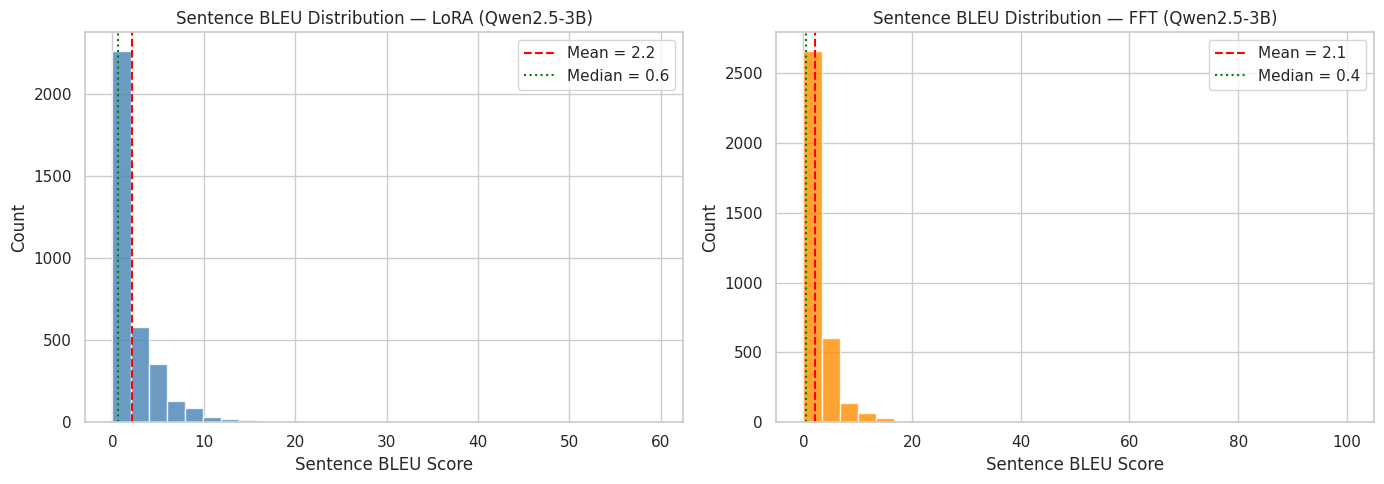

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, label, color in zip(
    axes,
    [sent_bleus_lora, sent_bleus_fft],
    ['LoRA (Qwen2.5-3B)', 'FFT (Qwen2.5-3B)'],
    ['steelblue', 'darkorange']
):
    ax.hist(scores, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(scores), color='red', linestyle='--',
               label=f'Mean = {np.mean(scores):.1f}')
    ax.axvline(np.median(scores), color='green', linestyle=':',
               label=f'Median = {np.median(scores):.1f}')
    ax.set_title(f'Sentence BLEU Distribution — {label}')
    ax.set_xlabel('Sentence BLEU Score')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'bleu_distributions.png', dpi=150)
plt.show()

## 5. Sample Qualitative Comparisons

In [8]:
with open(TEST_JSONL, encoding='utf-8') as f:
    test_records = [json.loads(line) for line in f if line.strip()]

N = 8
print(f'{"Modern English Source":<45} {"LoRA Output":<45} {"FFT Output":<45} {"Reference":<45}')
print('─' * 185)

for i in range(N):
    msgs = test_records[i]['messages']
    src  = next(m['content'] for m in msgs if m['role'] == 'user')
    ref  = next(m['content'] for m in msgs if m['role'] == 'assistant')

    def trunc(s, n=42):
        return s[:n] + '...' if len(s) > n else s

    print(f'{trunc(src):<45} {trunc(hyps_lora[i]):<45} {trunc(hyps_fft[i]):<45} {trunc(ref):<45}')

Modern English Source                         LoRA Output                                   FFT Output                                    Reference                                    
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Whatever I speak, I'll risk my life to pro... O noble duke!                                 What, what?                                     How high a pitch his resolution soars!Th...
Yes, you want to leave so you can join Ric... Why, what is that?                            What is your name?                              Most mighty sovereign,You have no cause ...
My lord, from Oxford I've sent the heads o... What! is it so?                               What sayst thou?                                Thy pains, Fitzwater, shall not be forgo...
He will die.                                  O my dear lord!                 